<a href="https://colab.research.google.com/github/bhatturvashi2618-sketch/capstoneproject2/blob/main/Copy_of_loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Business Understanding
## Project Overview

This project focuses on predicting loan default risk using machine learning techniques. By analyzing historical loan data and applicants' financial and credit-related information, the model classifies approved loans as either likely to be fully repaid or likely to default. The insights generated can support financial institutions in improving credit risk assessment and making more informed lending decisions.

## Problem Statement

Financial institutions face the challenge of identifying borrowers who are likely to default on their loans. Incorrect lending decisions can lead to financial losses and increased credit risk.

##Objective

Develop a machine learning model to predict whether an approved loan will be repaid or default based on the applicant's financial and credit information.

![](https://raw.githubusercontent.com/bhatturvashi2618-sketch/capstoneproject2/main/loanapproval.png)



**Import Libraries**

In [ ]:
#Data Manipulation
import pandas as pd
import numpy as np

In [ ]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
#Handle Missing Values
from sklearn.impute import SimpleImputer

In [ ]:
!pip install xgboost
#Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [ ]:
#Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#Cross Validation
from sklearn.model_selection import cross_val_score

In [ ]:
#Feature Importance
from sklearn.inspection import permutation_importance

In [ ]:
#Explainable AI (Optional but Recommended)
import shap

In [ ]:
#Save the Model
import joblib

#Data Source

The dataset used in this project was obtained from Kaggle. It is a publicly available Loan Approval Prediction dataset provided in CSV format.
The data was imported into Python using the Pandas library for preprocessing, exploratory data analysis, and machine learning model development.

#Constraints

The dataset contains missing values that require preprocessing.
Some categorical features must be encoded before model training.
The dataset is relatively small, so careful validation is needed to avoid overfitting.
The data is intended for educational and research purposes and may not fully represent real-world banking scenarios.

In [ ]:
# Setting this option will print all collumns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
accepted_df = pd.read_csv('/content/drive/My Drive/accepted_2007_to_2018Q4.csv', nrows=10000)
display(accepted_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68407277,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68355089,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300

#Data Dictionary
The dataset contains over 140 features, including borrower demographics, employment information, loan details, credit history, repayment records, and account balances. For brevity, only the key variables used in model development are described in this report.

#Exploratory Data Analysis (EDA) & Preprocessing

In [ ]:
#Identifiers such as id, member_id, url, and desc do not help the model learn patterns. They are unique for each loan or contain unnecessary text, so they should be removed.
# Drop identifier columns
columns_to_drop = [
    'id', 'member_id', 'url', 'desc', 'title', 'emp_title',
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term',
    'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date',
    'hardship_length', 'hardship_dpd',
    'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term'
]

accepted_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [ ]:
print('Columns in accepted_df:')
print(accepted_df.columns.tolist())

Columns in accepted_df:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 

In [ ]:
missing = pd.DataFrame({
    'Missing Values': accepted_df.isnull().sum(),
    'Percentage': (accepted_df.isnull().sum() / len(accepted_df)) * 100
})

missing = missing[missing['Missing Values'] > 0]
missing.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
sec_app_inq_last_6mths,10000,100.00
sec_app_earliest_cr_line,10000,100.00
sec_app_fico_range_high,10000,100.00
sec_app_fico_range_low,10000,100.00
sec_app_num_rev_accts,10000,100.00
sec_app_chargeoff_within_12_mths,10000,100.00
sec_app_collections_12_mths_ex_med,10000,100.00
sec_app_open_act_il,10000,100.00
sec_app_mths_since_last_major_derog,10000,100.00
sec_app_revol_util,10000,100.00


In [ ]:
#drop columns that have more than 70% of missing values
columns_to_drop = [
'sec_app_inq_last_6mths'	,
'sec_app_inq_last_6mths'	,
'sec_app_fico_range_high'	,
'sec_app_fico_range_low'	,
'sec_app_num_rev_accts'	,
'sec_app_chargeoff_within_12_mths'	,
'sec_app_collections_12_mths_ex_med'	,
'sec_app_open_act_il'	,
'sec_app_mths_since_last_major_derog'	,
'sec_app_revol_util'	,
'sec_app_open_acc'	,
'sec_app_mort_acc'	,
'revol_bal_joint'	,
'annual_inc_joint'	,
'verification_status_joint'	,
'dti_joint'	,
'mths_since_last_record'	,
'mths_since_recent_bc_dlq'	,
'mths_since_last_major_derog'
]

accepted_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


#axis=1 → Drop columns.
#thresh=threshold → Keep columns that have at least 70% non-missing values.
threshold = len(accepted_df) * 0.7
accepted_df = accepted_df.dropna(axis=1, thresh=threshold)

In [ ]:
missing = (accepted_df.isnull().sum() / len(accepted_df)) * 100
missing.sort_values(ascending=False)

,0
il_util,12.50
mths_since_recent_inq,10.73
num_tl_120dpd_2m,5.63
emp_length,5.49
mths_since_rcnt_il,2.40
...,...
tot_hi_cred_lim,0.00
total_bal_ex_mort,0.00
total_bc_limit,0.00
total_il_high_credit_limit,0.00


Check the Distribution of Numerical Columns

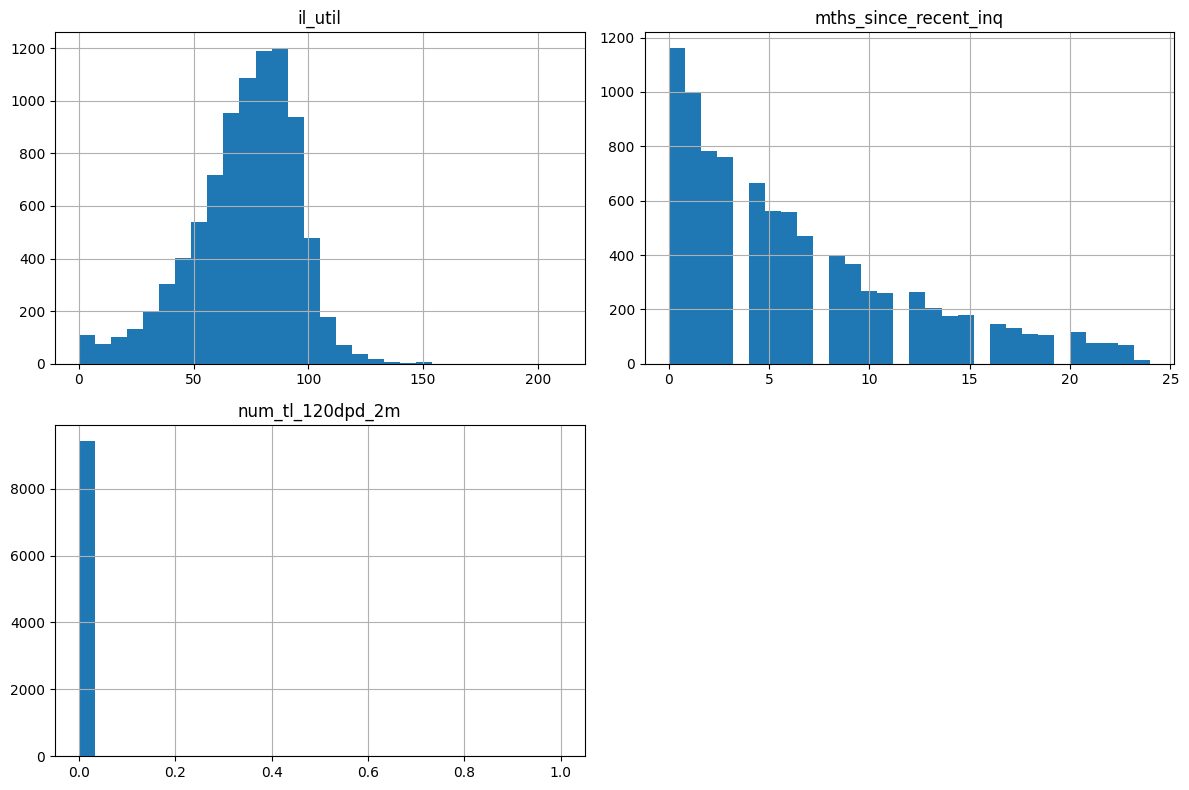

In [ ]:
columns = [
'il_util',
'mths_since_recent_inq',
'num_tl_120dpd_2m'
]

accepted_df[columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()
#data is skewed

In [ ]:
#check for skewness
print("il_util:", accepted_df['il_util'].skew())
print("mths_since_recent_inq:", accepted_df['mths_since_recent_inq'].skew())
print("num_tl_120dpd_2m:", accepted_df['num_tl_120dpd_2m'].skew())
print("num_tl_120dpd_2m:", accepted_df['num_tl_120dpd_2m'].skew())

il_util: -0.6449700087367188
mths_since_recent_inq: 1.0202590826581655
num_tl_120dpd_2m: 56.0684074453216
num_tl_120dpd_2m: 56.0684074453216


In [ ]:
accepted_df['il_util'] = accepted_df['il_util'].fillna(accepted_df['il_util'].median())
accepted_df['mths_since_recent_inq'] = accepted_df['mths_since_recent_inq'].fillna(accepted_df['mths_since_recent_inq'].median())

In [ ]:
#check for duplicates
accepted_df.duplicated().sum()

np.int64(0)

In [ ]:
#if exists
accepted_df.drop_duplicates(inplace=True)

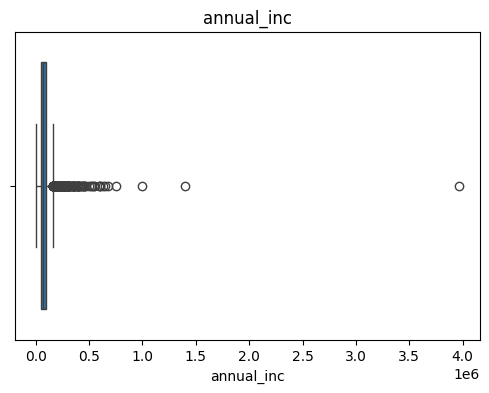

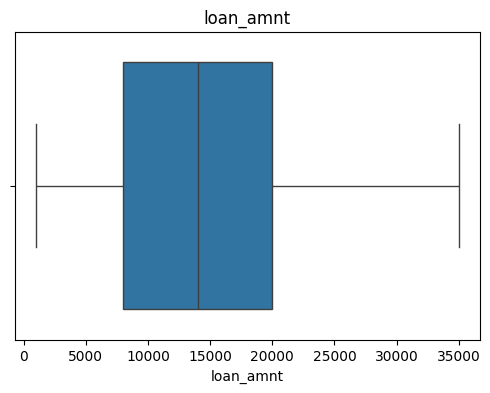

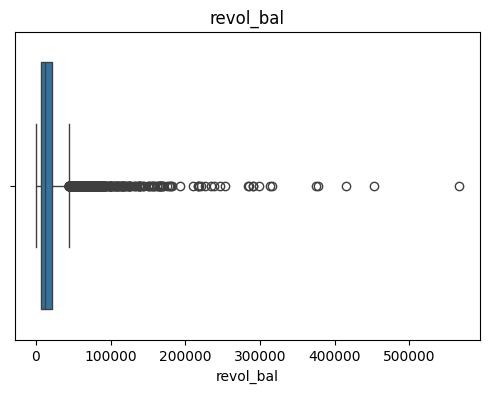

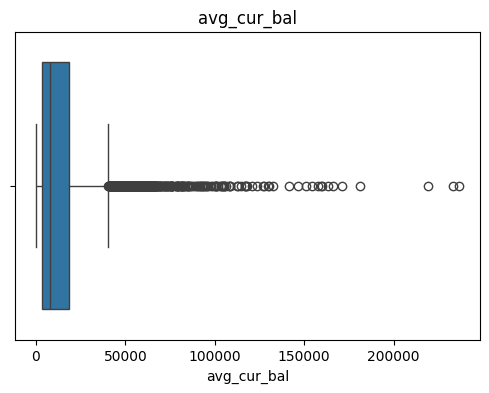

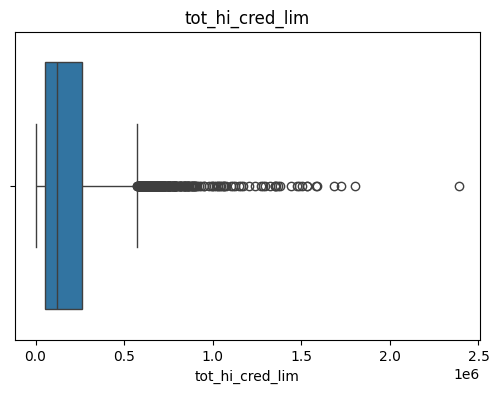

In [ ]:
#identify outliers
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'annual_inc',
    'loan_amnt',
    'revol_bal',
    'avg_cur_bal',
    'tot_hi_cred_lim'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=accepted_df[col])
    plt.title(col)
    plt.show()

In [ ]:
#shape before capping
print(accepted_df.shape)

(10000, 87)


In [ ]:
#capping the outliars
columns = [
    'revol_bal',
    'avg_cur_bal',
    'tot_hi_cred_lim'
]

for col in columns:
    Q1 = accepted_df[col].quantile(0.25)
    Q3 = accepted_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    accepted_df[col] = accepted_df[col].clip(lower=lower, upper=upper)

In [ ]:
#shape after capping
print(accepted_df.shape)

(10000, 87)


In [ ]:
#check for catogorical data
cat_cols = accepted_df.select_dtypes(include=['object', 'category']).columns

print(cat_cols.tolist())

['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'disbursement_method']


In [ ]:
# Define loan status categories
good = ["Fully Paid"]

bad = [
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Does not meet the credit policy. Status:Charged Off"
]

accepted_df = accepted_df[
    accepted_df["loan_status"].isin(good + bad)
].copy()

accepted_df["loan_status"] = accepted_df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Late (31-120 days)": 1,
    "Does not meet the credit policy. Status:Charged Off": 1
})

In [ ]:
#separate the target (loan_status) from data before calling get_dummies()
y = accepted_df['loan_status']
X = accepted_df.drop('loan_status', axis=1)

#Split numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

#fill missing values
# Numeric columns → median
num_imputer = SimpleImputer(strategy='median')
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

# Categorical columns → most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

print("Total NaNs:", X.isnull().sum().sum())
#One-hot encode all remaining categorical columns
categorical_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(X.shape)

Total NaNs: 0
(8960, 1457)


In [ ]:
print("loan_status" in accepted_df.columns)

True


In [ ]:
#find bad cols for xgboost
bad_cols = [col for col in X.columns if any(ch in col for ch in ['[', ']', '<'])]

print(bad_cols)

['emp_length_< 1 year']


In [ ]:
#clean col name
import re

# Clean all column names
X.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', str(col))
    for col in X.columns
]

In [ ]:
#Separate features and target
#train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7168, 1457)
X_test: (1792, 1457)
y_train: (7168,)
y_test: (1792,)


In [ ]:
print("Object columns:")
print(X_train.select_dtypes(include="object").columns.tolist())

print("Missing values:")
print(X_train.isnull().sum().sum())

print("Target classes:")
print(y_train.unique())

Object columns:
[]
Missing values:
0
Target classes:
[1 0]


In [ ]:
#Train Models
#Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
print(id(accepted_df))
print(id(y))

print(accepted_df["loan_status"].unique())
print(y.unique())

134506095382544
134506095391184
[0 1]
[0 1]


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#Make predictions on test data
lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

In [ ]:
#Create a comparison dataframe
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic_Regression": lr_pred,
    "Decision_Tree": dt_pred,
    "Random_Forest": rf_pred,
    "XGBoost": xgb_pred
})

prediction_df.head(20)

,Actual,Logistic_Regression,Decision_Tree,Random_Forest,XGBoost
0,1,1,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,1,1,1,0,0
5,0,1,0,0,1
6,1,0,1,0,0
7,0,0,0,0,0
8,0,0,0,0,0
9,0,0,1,0,0


In [ ]:
#number of predictions each model made
print("Logistic Regression:")
print(pd.Series(lr_pred).value_counts())

print("\nDecision Tree:")
print(pd.Series(dt_pred).value_counts())

print("\nRandom Forest:")
print(pd.Series(rf_pred).value_counts())

print("\nXGBoost:")
print(pd.Series(xgb_pred).value_counts())

Logistic Regression:
0    914
1    878
Name: count, dtype: int64

Decision Tree:
0    1428
1     364
Name: count, dtype: int64

Random Forest:
0    1749
1      43
Name: count, dtype: int64

XGBoost:
0    1637
1     155
Name: count, dtype: int64


In [ ]:
#Compare model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.580357,0.273349,0.677966,0.389610
1,Decision Tree,0.723214,0.304945,0.313559,0.309192
2,Random Forest,0.801897,0.488372,0.059322,0.105793
3,XGBoost,0.788504,0.419355,0.183616,0.255403


Visualization of comparision

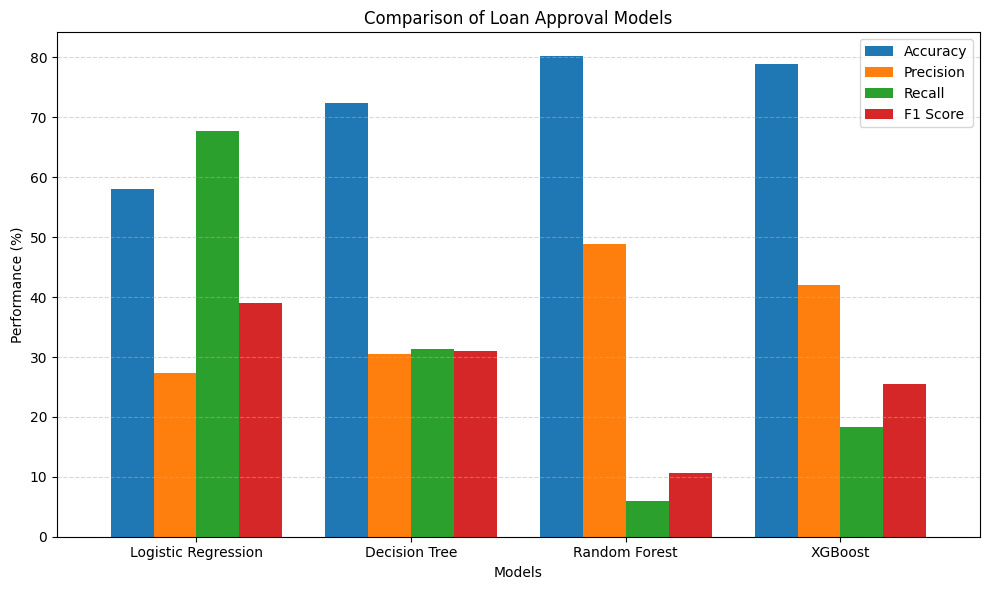

In [798]:
import matplotlib.pyplot as plt
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [58.04, 72.32, 80.19, 78.85],
    'Precision': [27.33, 30.49, 48.84, 41.94],
    'Recall': [67.80, 31.36, 5.93, 18.36],
    'F1 Score': [38.96, 30.92, 10.58, 25.54]
})

comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6),
    width=0.8
)

plt.title('Comparison of Loan Approval Models')
plt.xlabel('Models')
plt.ylabel('Performance (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

ROC Curve

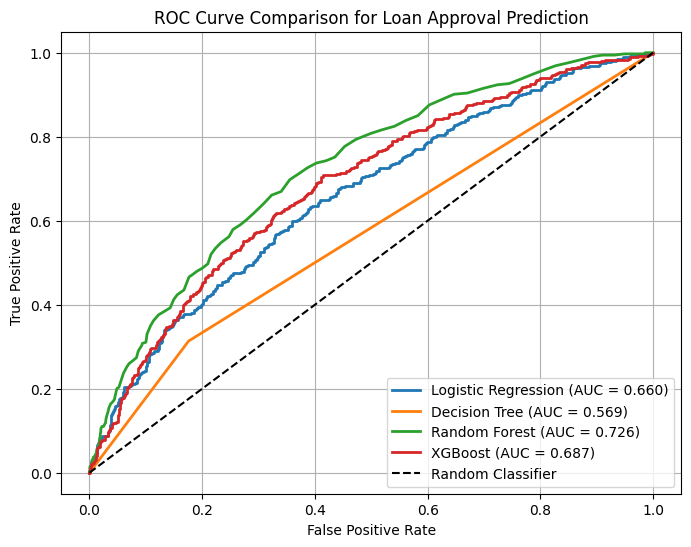

In [800]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Dictionary of trained models
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    # Probability of positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Random classifier line
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Loan Approval Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Feature importance plot

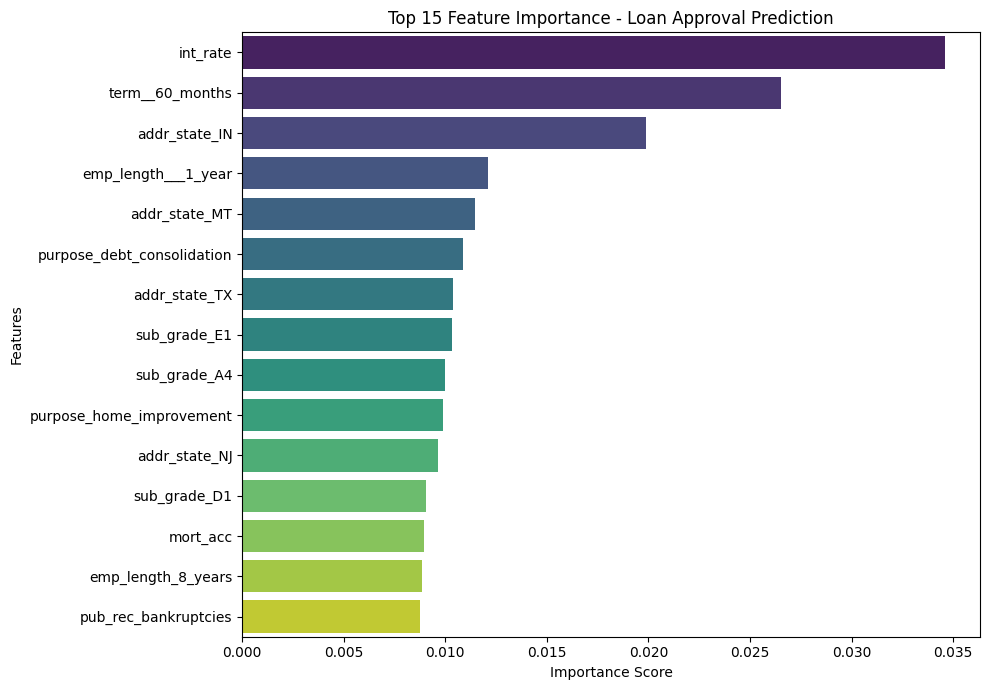

In [801]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 15 Feature Importance - Loan Approval Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [ ]:
#Evaluate
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

pred = xgb.predict(X_test)

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

print(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.82      0.94      0.88      1438
           1       0.42      0.18      0.26       354

    accuracy                           0.79      1792
   macro avg       0.62      0.56      0.57      1792
weighted avg       0.74      0.79      0.75      1792

[[1348   90]
 [ 289   65]]
0.6868728538538303


#Conclusion


Among the evaluated models, Random Forest achieved the highest accuracy of 80.19%, while Logistic Regression achieved the highest recall for identifying default cases (67.80%). Since loan default prediction is a risk-sensitive problem, recall is an important evaluation metric. XGBoost provided a balanced performance with 78.85% accuracy and better generalization capability. Therefore, XGBoost was selected as the final model, with further improvements planned through hyperparameter tuning and class imbalance handling.